# Race Simulation — The Elimination Stage

A cup (Cup of the Week) has three stages:
1. **Qualification** — 64 players selected from the full field
2. **Race** — 39 elimination rounds determine finish positions 1–64
3. **Scoring** — finish positions mapped to points

This notebook focuses on **stage 2: the race**.
Given 64 qualifiers already selected, what finish positions does the simulation produce?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tmonacodel.config import TournamentConfig
from tmonacodel.scoring import build_finish_position_lookup
from tmonacodel.race import simulate_race

sns.set_theme(style='whitegrid')

config = TournamentConfig(n_players=128, random_seed=42)
finish_pos_lookup = build_finish_position_lookup(config)

print(f"Qualifiers per race: {config.n_qualifiers}")
print(f"Elimination stages: {config.elimination_stages}")

Qualifiers per race: 64
Elimination stages: ((24, 2), (15, 1))


## 
The finish position lookup

The race uses a single random permutation of 64 qualifiers.
The `finish_pos_lookup` array maps a permutation index to a finish position:
- index 0 → first eliminated (worst finish)
- index 63 → last standing (1st place)

Players eliminated together in a double-elimination round get consecutive unique positions
(e.g. 48 and 49) so each of the 64 positions appears exactly once in the lookup.

In [2]:
lookup_series = pd.Series(
    finish_pos_lookup,
    index=pd.RangeIndex(len(finish_pos_lookup), name="perm_index"),
    name="finish_position",
)
print("Worst finishes (perm_index 0-4):")
print(lookup_series.head(5).to_string())
print("\nBest finishes (perm_index 60-63):")
print(lookup_series.tail(4).to_string())
print(f"\nAll 64 positions unique: {lookup_series.nunique() == config.n_qualifiers}")

Worst finishes (perm_index 0-4):
perm_index
0    64
1    63
2    62
3    61
4    60

Best finishes (perm_index 60-63):
perm_index
60    4
61    3
62    2
63    1

All 64 positions unique: True


## Simulating one race

Given 64 qualifiers (indexed 0-63), `simulate_race` returns their finish positions directly.
No qualification step, no scoring — just the elimination result.

In [3]:
rng = np.random.default_rng(42)
finish_positions = simulate_race(config.n_qualifiers, finish_pos_lookup, rng)

result_df = pd.DataFrame({
    "qualifier_index": np.arange(config.n_qualifiers),
    "finish_position": finish_positions,
}).sort_values("finish_position").reset_index(drop=True)

print("Top 10 finishers:")
result_df.head(10)

Top 10 finishers:


,qualifier_index,finish_position
0,8,1
1,13,2
2,1,3
3,33,4
4,36,5
5,2,6
6,62,7
7,14,8
8,43,9
9,53,10


## Running 10,000 races — is the distribution uniform?

Track qualifier index 0 across 10,000 races.
With purely random mechanics every qualifier is equally likely to receive any finish position,
so the histogram should be flat across positions 1-64.

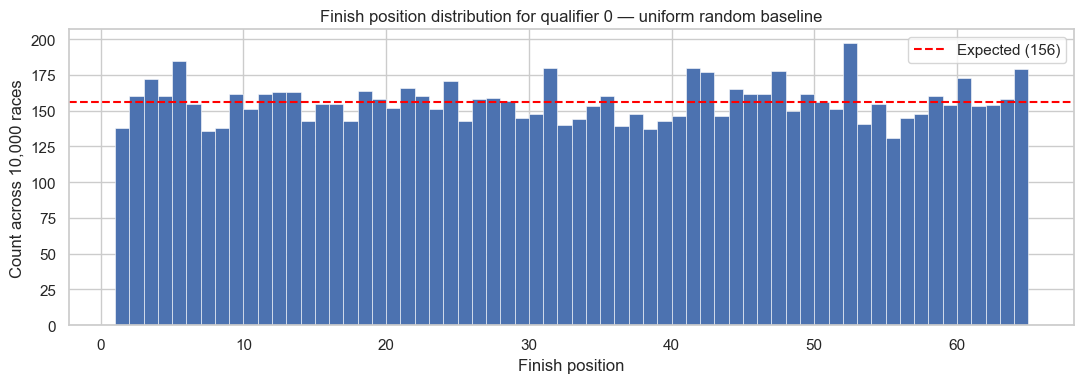

Mean finish position: 32.59 (expected 32.50)


In [4]:
n_trials = 10_000
target = 0

rng = np.random.default_rng(42)
recorded = np.empty(n_trials, dtype=np.int64)

for i in range(n_trials):
    fp = simulate_race(config.n_qualifiers, finish_pos_lookup, rng)
    recorded[i] = fp[target]

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(recorded, bins=range(1, config.n_qualifiers + 2), edgecolor='white', linewidth=0.4)
ax.set_xlabel("Finish position")
ax.set_ylabel("Count across 10,000 races")
ax.set_title("Finish position distribution for qualifier 0 — uniform random baseline")
expected = n_trials / config.n_qualifiers
ax.axhline(expected, color='red', linestyle='--', label=f'Expected ({expected:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean finish position: {recorded.mean():.2f} (expected {(config.n_qualifiers + 1) / 2:.2f})")

## Skilled race: Plackett-Luce model

When `qualifier_skills` is passed to `simulate_race`, finish order is drawn from a
**Plackett-Luce** distribution via Gumbel noise:

```
score_i = Gumbel() + log(skill_i)
```

Players are ranked by score — higher is better. A player with `skill=1.0` (log=0) gets
pure Gumbel noise. A player with `skill=10` gets a +2.3 boost, roughly 1.8 standard
deviations above the field.

When all skills are equal the ordering is statistically identical to a uniform permutation.

In [5]:
from tmonacodel.player import Player

# Define 64 qualifiers with three distinct skill tiers
# Elite (skill=1.0): players 0-4  — top-5 consistently dominant
# Solid (skill=0.35): players 5-29 — competent mid-field
# Weak  (skill=0.08): players 30-63 — generic fill

n_elite, n_solid, n_weak = 5, 25, 34
skill_tiers = (
    [(f"Elite_{i}", 1.0) for i in range(n_elite)]
    + [(f"Solid_{i}", 0.35) for i in range(n_solid)]
    + [(f"Weak_{i}", 0.08) for i in range(n_weak)]
)
player_names = [name for name, _ in skill_tiers]
qualifier_skills = np.array([skill for _, skill in skill_tiers], dtype=float)

print(f"Qualifier breakdown: {n_elite} elite (skill=1.0) | {n_solid} solid (skill=0.35) | {n_weak} weak (skill=0.08)")
print(f"Plackett-Luce win probability ∝ skill / sum(skills):")
total = qualifier_skills.sum()
for label, skill in [("Elite player", 1.0), ("Solid player", 0.35), ("Weak player", 0.08)]:
    print(f"  {label}: {skill / total:.4f}")

Qualifier breakdown: 5 elite (skill=1.0) | 25 solid (skill=0.35) | 34 weak (skill=0.08)
Plackett-Luce win probability ∝ skill / sum(skills):
  Elite player: 0.0607
  Solid player: 0.0213
  Weak player: 0.0049


In [6]:
n_trials = 10_000
rng = np.random.default_rng(42)

# Record finish positions for one representative from each tier
tracked = {"Elite_0": 0, "Solid_0": 5, "Weak_0": 30}
finish_records = {name: np.empty(n_trials, dtype=np.int64) for name in tracked}

for i in range(n_trials):
    fp = simulate_race(config.n_qualifiers, finish_pos_lookup, rng, qualifier_skills=qualifier_skills)
    for name, idx in tracked.items():
        finish_records[name][i] = fp[idx]

# Summary stats
print("Finish position statistics over 10,000 skilled races:\n")
print(f"{'Player':<10} {'Tier':<8} {'Mean':>6} {'Median':>8} {'Top-8 %':>9}")
print("-" * 45)
for name, idx in tracked.items():
    tier = "Elite" if idx < n_elite else ("Solid" if idx < n_elite + n_solid else "Weak")
    data = finish_records[name]
    print(f"{name:<10} {tier:<8} {data.mean():6.1f} {int(np.median(data)):8d} {(data <= 8).mean()*100:8.1f}%")

Finish position statistics over 10,000 skilled races:

Player     Tier       Mean   Median   Top-8 %
---------------------------------------------
Elite_0    Elite      12.0       10     43.3%
Solid_0    Solid      23.1       22     17.4%
Weak_0     Weak       42.7       47      4.3%


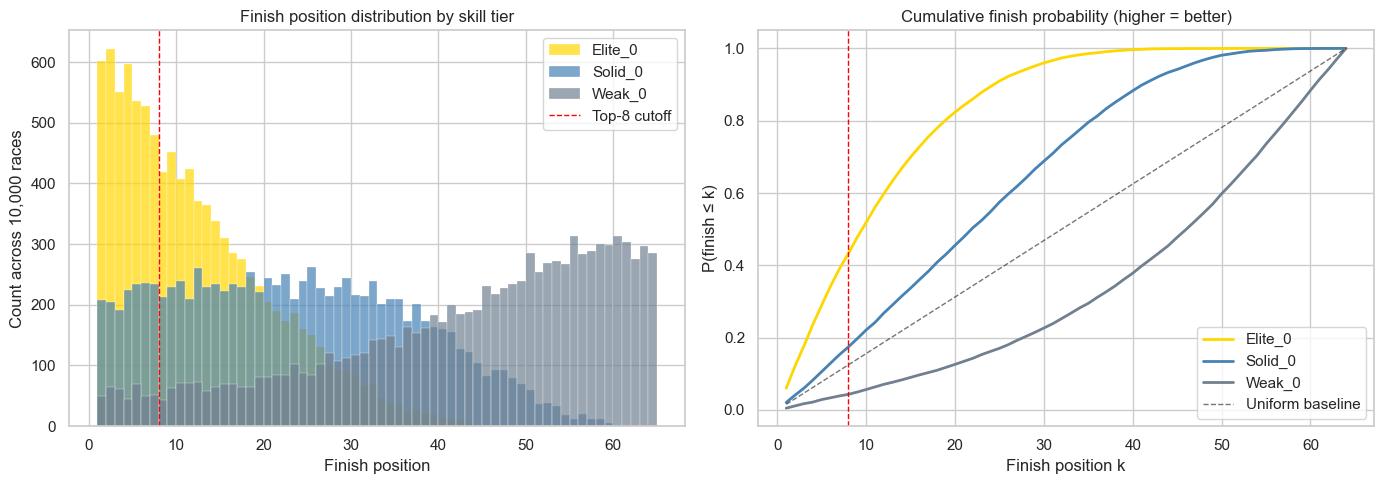

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colours = {"Elite_0": "gold", "Solid_0": "steelblue", "Weak_0": "slategray"}
bins = range(1, config.n_qualifiers + 2)

# Left: finish position histograms per tier
for name, data in finish_records.items():
    axes[0].hist(data, bins=bins, alpha=0.7, label=name, color=colours[name], edgecolor='white', linewidth=0.3)
axes[0].axvline(8, color='red', linestyle='--', linewidth=1, label='Top-8 cutoff')
axes[0].set_xlabel('Finish position')
axes[0].set_ylabel('Count across 10,000 races')
axes[0].set_title('Finish position distribution by skill tier')
axes[0].legend()

# Right: cumulative P(finish ≤ k) for each tier — shows "probability of making top-k"
positions = np.arange(1, config.n_qualifiers + 1)
for name, data in finish_records.items():
    cdf = [(data <= k).mean() for k in positions]
    axes[1].plot(positions, cdf, label=name, color=colours[name], linewidth=2)

# Uniform baseline
uniform_cdf = positions / config.n_qualifiers
axes[1].plot(positions, uniform_cdf, 'k--', linewidth=1, label='Uniform baseline', alpha=0.6)
axes[1].axvline(8, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Finish position k')
axes[1].set_ylabel('P(finish ≤ k)')
axes[1].set_title('Cumulative finish probability (higher = better)')
axes[1].legend()

plt.tight_layout()
plt.show()